Çoklu Doğrusal Regresyon

In [1]:
import pandas as pd

df = pd.read_csv("../resources/student_performance.csv")

print(df.head(3))
print(df.info())


   study_hours_per_week  attendance_rate  sleep_hours_per_day  \
0                  22.0             57.0                  4.6   
1                  30.0             84.0                  4.9   
2                   8.0             64.0                  6.8   

   solved_question_count  previous_term_score  internet_usage_hours_per_day  \
0                  643.0                 66.0                           2.2   
1                  944.0                 39.0                           0.7   
2                  134.0                 60.0                           5.9   

   final_exam_score  
0              89.9  
1              96.3  
2              66.6  
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   study_hours_per_week          1976 non-null   float64
 1   attendance_rate               1964 non-null   float64
 2 

In [2]:
print(df.isnull().sum())


study_hours_per_week            24
attendance_rate                 36
sleep_hours_per_day             50
solved_question_count           30
previous_term_score             20
internet_usage_hours_per_day    44
final_exam_score                16
dtype: int64


In [5]:
features = [
    "study_hours_per_week",
    "attendance_rate",
    "sleep_hours_per_day",
    "solved_question_count",
    "previous_term_score",
    "internet_usage_hours_per_day",
]

for col in features:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

df_model = df.dropna(subset =["final_exam_score"]).copy()

print(df_model.isnull().sum())


study_hours_per_week             0
attendance_rate                  0
sleep_hours_per_day              0
solved_question_count            0
previous_term_score              0
internet_usage_hours_per_day     0
final_exam_score                16
dtype: int64
study_hours_per_week            0
attendance_rate                 0
sleep_hours_per_day             0
solved_question_count           0
previous_term_score             0
internet_usage_hours_per_day    0
final_exam_score                0
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

X = df_model[features]
y = df_model["final_exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("R2 Train :", r2_score(y_train, y_pred_train))
print("R2 Test :", r2_score(y_test, y_pred_test))



R2 Train : 0.7646887306397252
R2 Test : 0.7526629979399492


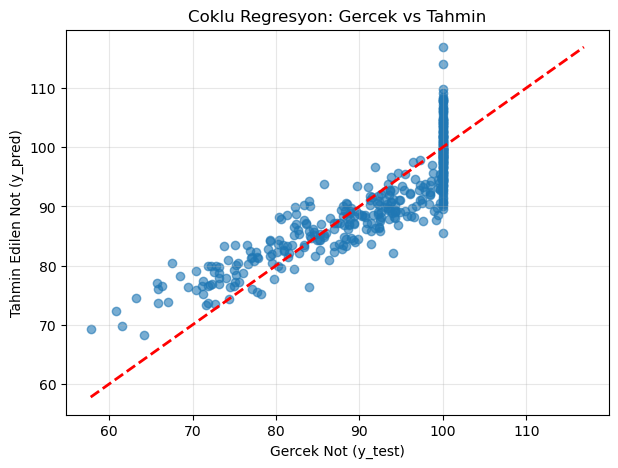

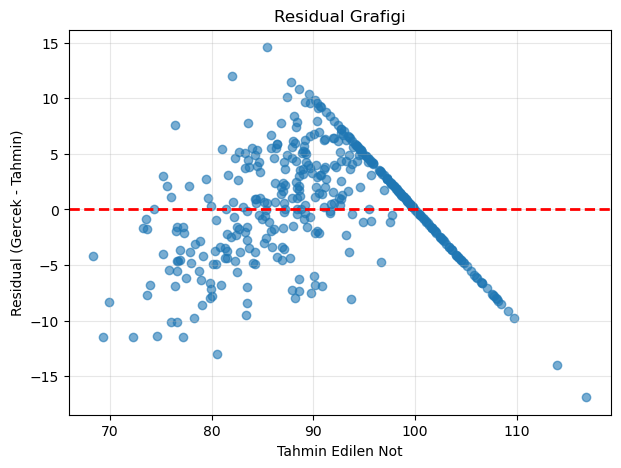

RMSE: 4.984


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

# Test verisi üzerinde tahmin al
y_pred_test = model.predict(X_test)

# 1) Gercek vs Tahmin grafigi
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6)

line_min = min(y_test.min(), y_pred_test.min())
line_max = max(y_test.max(), y_pred_test.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", linewidth=2)

plt.xlabel("Gercek Not (y_test)")
plt.ylabel("Tahmin Edilen Not (y_pred)")
plt.title("Coklu Regresyon: Gercek vs Tahmin")
plt.grid(alpha=0.3)
plt.show()

# 2) Residual (hata) grafigi
residuals = y_test - y_pred_test

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_test, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Tahmin Edilen Not")
plt.ylabel("Residual (Gercek - Tahmin)")
plt.title("Residual Grafigi")
plt.grid(alpha=0.3)
plt.show()

# 3) Kisa metrik kontrolu
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("RMSE:", round(rmse, 3))
